In [1]:
# Lecture des données
price_resid <- read.csv("../data/deseasonalised/price_resid.csv", row.names = 1)

# Série
price_res <- price_resid$price_deseasoned

# Modèle ARIMA(3,0,2) sans constante
price_model <- arima(price_res, order = c(3,0,1), include.mean = FALSE, method = "CSS-ML")

# Coefficients
coef(price_model)

aic <- price_model$aic
print(aic)
# Standard errors
se <- sqrt(diag(price_model$var.coef))
print(se)
summary(price_model)

ar1         ar2         ar3         ma1 
 1.13764422 -0.29083730  0.08631512 -0.01688607

[1] -166299.2
       ar1        ar2        ar3        ma1 
0.09436108 0.10438903 0.01789071 0.09484443 


          Length Class  Mode     
coef          4  -none- numeric  
sigma2        1  -none- numeric  
var.coef     16  -none- numeric  
mask          4  -none- logical  
loglik        1  -none- numeric  
aic           1  -none- numeric  
arma          7  -none- numeric  
residuals 26281  ts     numeric  
call          5  -none- call     
series        1  -none- character
code          1  -none- numeric  
n.cond        1  -none- numeric  
nobs          1  -none- numeric  
model        10  -none- list     

In [ ]:
library(yuima)

df <- read.csv("../data/deseasonalised/price_resid.csv", row.names = 1)
y  <- as.numeric(df[["price_deseasoned"]])
y  <- y[is.finite(y)]
y  <- y - mean(y)
h  <- 1
tt <- (0:(length(y)-1)) * h

dat <- setData(matrix(y, ncol = 1), delta = h)
mod <- setCarma(p = 3, q = 2, scale.par = "sig", Carma.var = "y")
yu  <- setYuima(model = mod, data = dat)

start <- list(
  a1  = 5.57275421,
  a2  = 3.22406797,
  a3  = 0.19671536,
  b0  = 1,
  b1  = 3.07,
  b2  = 0.88,
  sig = 0.029
)

cat("=== PARAMETRES INITIAUX ===\n")
for(nm in names(start)) {
  cat(sprintf("  %-6s = %g\n", nm, start[[nm]]))
}

est <- suppressWarnings(qmle(
  yuima  = yu,
  start  = start,
  lower  = list(sig = 1e-6),
  method = "L-BFGS-B"
))

cf      <- coef(est)
loglik  <- -est@min
n_params <- length(cf)
aic     <- 2 * n_params - 2 * loglik

cat("\n=== PARAMETRES ESTIMES ===\n")
for(nm in names(cf)) {
  cat(sprintf("  %-6s = %g\n", nm, cf[[nm]]))
}

cat("\n=== CRITERES ===\n")
cat(sprintf("  log-lik = %.4f\n", loglik))
cat(sprintf("  n_params = %d\n",  n_params))
cat(sprintf("  AIC      = %.4f\n", aic))

Le chargement a nécessité le package : zoo


Attachement du package : 'zoo'


Les objets suivants sont masqués depuis 'package:base':

    as.Date, as.Date.numeric


Le chargement a nécessité le package : stats4

Le chargement a nécessité le package : expm

Le chargement a nécessité le package : Matrix


Attachement du package : 'expm'


L'objet suivant est masqué depuis 'package:Matrix':

    expm


Le chargement a nécessité le package : cubature

Le chargement a nécessité le package : mvtnorm

########################################

This is YUIMA Project package v.1.15.34

Why don't you try yuimaGUI package?

Visit: http://www.yuima-project.com

########################################


Attachement du package : 'yuima'


L'objet suivant est masqué depuis 'package:stats':

    simulate




=== PARAMETRES INITIAUX ===
  a1     = 5.57275
  a2     = 3.22407
  a3     = 0.196715
  b0     = 1
  b1     = 3.07
  b2     = 0.88
  sig    = 0.029

Starting qmle for carma ... 

=== PARAMETRES ESTIMES ===
  sig    = 0.0298449
  b2     = 0.0262929
  b0     = 1
  b1     = 2.1896
  a3     = 0.223416
  a2     = 2.74704
  a1     = 6.07703

=== CRITERES ===
  log-lik = 82964.4716
  n_params = 7
  AIC      = -165914.9433


In [14]:
library(yuima)

df <- read.csv("../data/deseasonalised/price_resid.csv", row.names = 1)
y  <- as.numeric(df[["price_deseasoned"]])
y  <- y[is.finite(y)]
y  <- y - mean(y)

# delta = 1 heure en années
h <- 1/8760

dat <- setData(matrix(y, ncol = 1), delta = h)
mod <- setCarma(p = 3, q = 2, scale.par = "sig", Carma.var = "y")
yu  <- setYuima(model = mod, data = dat)

# Paramètres initiaux : A_yr = 8760 * A_h
# b et sig inchangés
scale <- 8760

# Matrice compagnon en h^-1
a_h <- c(5.57275421, 3.22406797, 0.19671536)
A_h <- matrix(0, 3, 3)
A_h[1,2] <- 1; A_h[2,3] <- 1
A_h[3,] <- -rev(a_h)

# Conversion : A_yr = 8760 * A_h
A_yr <- scale * A_h

# Coefficients AR en yr^-1 depuis A_yr
# A_yr[3,] = [-a3_yr, -a2_yr, -a1_yr]
a1_yr <- -A_yr[3,3]
a2_yr <- -A_yr[3,2]
a3_yr <- -A_yr[3,1]

start <- list(
  a1  = a1_yr,
  a2  = a2_yr,
  a3  = a3_yr,
  b0  = 1,
  b1  = 3.07,    # b inchangé
  b2  = 0.88,    # b inchangé
  sig = 2.793    # sig inchangé
)

cat("=== PARAMETRES INITIAUX (yr^-1) ===\n")
for(nm in names(start)) {
  cat(sprintf("  %-6s = %g\n", nm, start[[nm]]))
}

est <- suppressWarnings(qmle(
  yuima  = yu,
  start  = start,
  lower  = list(sig = 1e-6),
  method = "L-BFGS-B"
))

cf       <- coef(est)
loglik   <- -est@min
n_params <- length(cf)
aic      <- 2 * n_params - 2 * loglik

cat("\n=== PARAMETRES ESTIMES (yr^-1) ===\n")
for(nm in names(cf)) {
  cat(sprintf("  %-6s = %g\n", nm, cf[[nm]]))
}

# Valeurs propres et demi-vies depuis A_yr estimé
a_final <- c(cf["a1"], cf["a2"], cf["a3"])
A_final <- matrix(0, 3, 3)
A_final[1,2] <- 1; A_final[2,3] <- 1
A_final[3,] <- -rev(a_final)
eigs <- eigen(A_final)$values

cat("\n=== VALEURS PROPRES (yr^-1) ===\n")
for(e in eigs) {
  cat(sprintf("  lambda = %g yr^-1  ->  demi-vie = %.2f h\n",
              Re(e), log(2)/abs(Re(e)) * 8760))
}

cat("\n=== STATIONNARITE ===\n")
if(all(Re(eigs) < 0)) {
  cat("  OK — modele stationnaire\n")
} else {
  cat("  ATTENTION — valeurs propres a partie reelle positive\n")
}

cat("\n=== CRITERES ===\n")
cat(sprintf("  log-lik  = %.4f\n", loglik))
cat(sprintf("  n_params = %d\n",   n_params))
cat(sprintf("  AIC      = %.4f\n", aic))

=== PARAMETRES INITIAUX (yr^-1) ===
  a1     = 48817.3
  a2     = 28242.8
  a3     = 1723.23
  b0     = 1
  b1     = 3.07
  b2     = 0.88
  sig    = 2.793

Starting qmle for carma ... 

=== PARAMETRES ESTIMES (yr^-1) ===
  sig    = 139.966
  b2     = -3.44942e-08
  b0     = 1
  b1     = 379.853
  a3     = 1723.24
  a2     = 28242.8
  a1     = 48817.3

=== VALEURS PROPRES (yr^-1) ===
  lambda = -48816.7 yr^-1  ->  demi-vie = 0.12 h
  lambda = -0.509227 yr^-1  ->  demi-vie = 11923.91 h
  lambda = -0.0693214 yr^-1  ->  demi-vie = 87591.51 h

=== STATIONNARITE ===
  OK — modele stationnaire

=== CRITERES ===
  log-lik  = 82495.8665
  n_params = 7
  AIC      = -164977.7329


In [16]:
# En R avec tes paramètres initiaux
library(Matrix)


df <- read.csv("../data/deseasonalised/price_resid.csv", row.names = 1)
y  <- as.numeric(df[["price_deseasoned"]])
y  <- y[is.finite(y)]
y  <- y - mean(y)

a_init <- c(5.573, 3.224, 0.197)
b_init <- c(1, 3.07, 0.88)  # b0=1, b1, b2

# Matrice compagnon
p <- 3
A <- matrix(0, p, p)
for(i in 1:(p-1)) A[i, i+1] <- 1
A[p, ] <- -rev(a_init)

# Lyapunov : A*Sigma + Sigma*A^T + ep*ep^T = 0
ep <- matrix(0, p, 1); ep[p] <- 1
Q <- ep %*% t(ep)

# lyapunov en R via package
library(Matrix)
Sigma_norm <- solve(
  kronecker(diag(p), A) + kronecker(A, diag(p)),
  -as.vector(Q)
)
Sigma_norm <- matrix(Sigma_norm, p, p)

# b vecteur (padded à longueur p)
b_vec <- c(b_init, rep(0, p - length(b_init)))

# variance normalisée
var_norm <- t(b_vec) %*% Sigma_norm %*% b_vec

# sigma initial
sig_init <- sd(y) / sqrt(var_norm)
print(sig_init)

           [,1]
[1,] 0.02871412


Warning message:
"le package 'GeneralizedHyperbolic' a été compilé avec la version R 4.5.3"


Lyapunov convergé en 2 itérations
Gain stationnaire convergé en 1 itérations
Lambda_r    : -0.06932144 
b(lambda_r) : -3545.604 
1/alpha_r   : -6.056705 

=== LEVY INCREMENTS ===
N    : 26280 
Mean : 0 
SD   : 0.009788 
Skew : 0.0496 
Kurt : 9.1313 

Fit NIG...

Params NIG:
           mu         delta         alpha          beta 
 0.0004452303  0.0060635604 63.1574404603 -4.6222791378 

=== GOF ===
AIC Gauss: -168591.3 
AIC NIG  : -175803.7 
Delta AIC: 7212.4 => NIG meilleur si positif

Sauvegardé: 26280 incréments prix


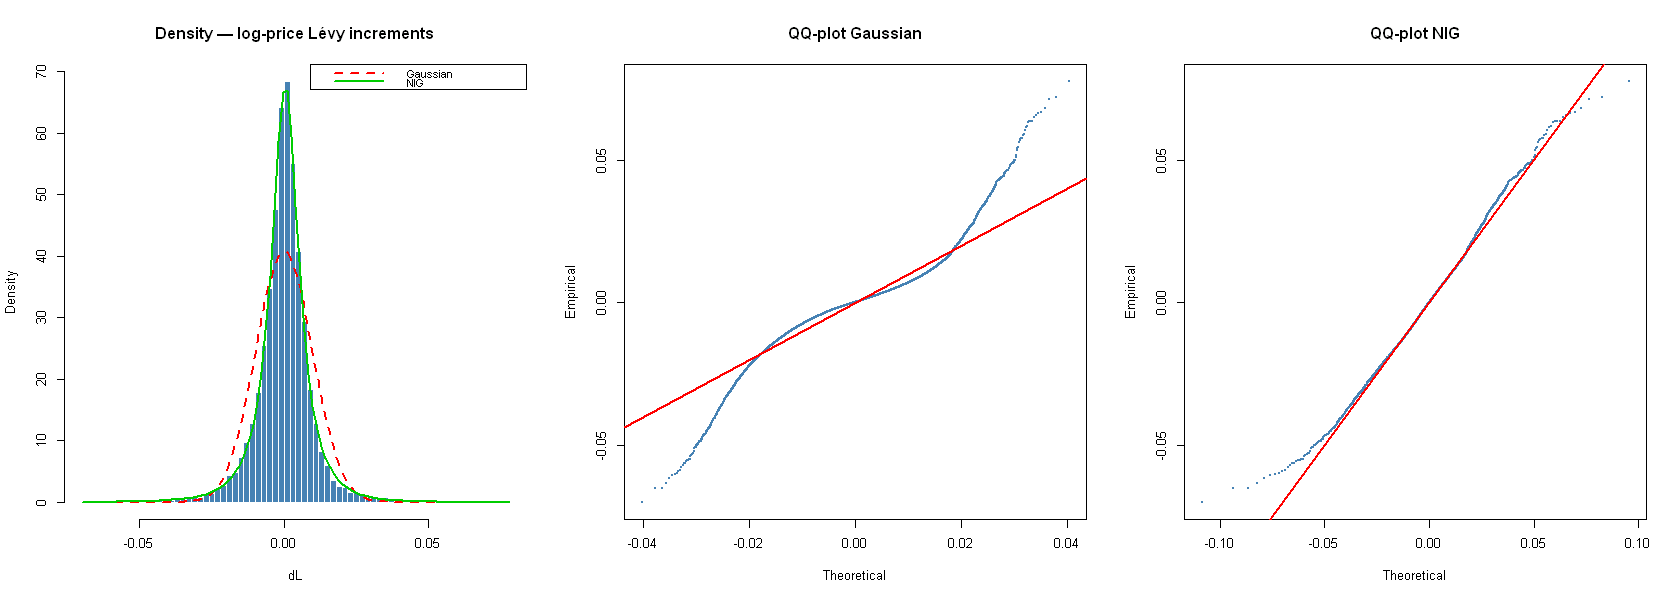

: 

In [ ]:
library(expm)
library(GeneralizedHyperbolic)

h <- 1/8760

df <- read.csv("../data/deseasonalised/price_resid.csv", row.names = 1)
y  <- as.numeric(df[["price_deseasoned"]])
y  <- y[is.finite(y)]
y  <- y - mean(y)

# ==================================================
# Paramètres
# ==================================================
cf        <- coef(est)
ar.par    <- c(cf["a1"], cf["a2"], cf["a3"])
ma.par    <- c(cf["b0"], cf["b1"], cf["b2"]) * cf["sig"]
p         <- length(ar.par)
q         <- length(ma.par)
n         <- length(y)

# ==================================================
# Matrice companion A
# ==================================================
A <- matrix(0, p, p)
if (p > 1) for (i in 1:(p-1)) A[i, i+1] <- 1
A[p, ] <- -ar.par[p:1]

b_vec      <- rep(0, p)
b_vec[1:q] <- ma.par
e_p        <- rep(0, p); e_p[p] <- 1
eAh        <- expm(A * h)
R_obs      <- .Machine$double.eps * var(y)
Q_proc     <- (e_p %o% e_p) * h

# ==================================================
# Variance stationnaire — critère relaxé
# ==================================================
Q_inf <- matrix(0, p, p)
for (k in 1:100000) {
  Q_new <- eAh %*% Q_inf %*% t(eAh) + Q_proc
  if (max(abs(Q_new - Q_inf)) < 1e-8) break
  Q_inf <- Q_new
}
cat("Lyapunov convergé en", k, "itérations\n")

# ==================================================
# Gain de Kalman stationnaire — critère relaxé
# ==================================================
P_ss <- Q_inf
for (k in 1:10000) {
  Pp       <- eAh %*% P_ss %*% t(eAh) + Q_proc
  S_ss     <- as.numeric(t(b_vec) %*% Pp %*% b_vec) + R_obs
  K_ss     <- (Pp %*% b_vec) / S_ss
  P_ss_new <- (diag(p) - K_ss %*% t(b_vec)) %*% Pp
  if (max(abs(P_ss_new - P_ss)) < 1e-8) break
  P_ss <- P_ss_new
}
cat("Gain stationnaire convergé en", k, "itérations\n")

Pp_stat <- eAh %*% P_ss %*% t(eAh) + Q_proc
K_stat  <- (Pp_stat %*% b_vec) /
           (as.numeric(t(b_vec) %*% Pp_stat %*% b_vec) + R_obs)

# ==================================================
# Filtre de Kalman
# ==================================================
X_f <- matrix(0, n, p)
for (i in 2:n) {
  Xp      <- as.numeric(eAh %*% X_f[i-1,])
  X_f[i,] <- Xp + K_stat * (y[i] - sum(b_vec * Xp))
}
X.StVa <- t(X_f)

# ==================================================
# État canonique
# ==================================================
eig_A     <- eigen(A)
eig_vals  <- eig_A$values
eig_vecs  <- eig_A$vectors
BinLambda <- sapply(eig_vals, function(lam) sum(ma.par * lam^(0:(q-1))))
Y_CVS     <- diag(BinLambda) %*% solve(eig_vecs) %*% X.StVa

# Valeur propre réelle dominante
idx_real <- which(abs(Im(eig_vals)) < 1e-6)
if (length(idx_real) == 0) {
  cat("ATTENTION: aucune vp réelle — utilisation Re(vp[1])\n")
  idx_r    <- 1
  lambda_r <- Re(eig_vals[1])
} else {
  idx_r    <- idx_real[which.max(Re(eig_vals[idx_real]))]
  lambda_r <- Re(eig_vals[idx_r])
}
cat("Lambda_r    :", lambda_r, "\n")
cat("b(lambda_r) :", Re(BinLambda[idx_r]), "\n")

# a'(lambda_r)
ar_coeffs <- c(1, ar.par[1:p])
derA      <- sum(sapply(1:p, function(k)
               (p+1-k) * ar_coeffs[k] * lambda_r^(p-k)))
coeff     <- Re(derA / BinLambda[idx_r])
cat("1/alpha_r   :", coeff, "\n")

# ==================================================
# Formule (16) — trapèze
# ==================================================
Y_r     <- Re(Y_CVS[idx_r, ])
lev_und <- numeric(n)
int_cum <- 0
for (t in 2:n) {
  int_cum    <- int_cum + 0.5 * (Y_r[t-1] + Y_r[t]) * h
  lev_und[t] <- coeff * (Y_r[t] - Y_r[1] - lambda_r * int_cum)
}
dL <- diff(lev_und)
dL <- dL[is.finite(dL)]

cat("\n=== LEVY INCREMENTS ===\n")
cat("N    :", length(dL), "\n")
cat("Mean :", round(mean(dL), 6), "\n")
cat("SD   :", round(sd(dL),   6), "\n")
cat("Skew :", round(mean((dL-mean(dL))^3)/sd(dL)^3, 4), "\n")
cat("Kurt :", round(mean((dL-mean(dL))^4)/sd(dL)^4, 4), "\n")

# ==================================================
# Fit NIG
# ==================================================
cat("\nFit NIG...\n")
fit_nig    <- nigFit(dL)
params_nig <- fit_nig$param
cat("\nParams NIG:\n"); print(params_nig)

probs <- ppoints(length(dL))
q_emp <- sort(dL)
q_nig <- qnig(probs, mu=params_nig["mu"], delta=params_nig["delta"],
              alpha=params_nig["alpha"], beta=params_nig["beta"])
q_nor <- qnorm(probs, mean(dL), sd(dL))

options(repr.plot.width=14, repr.plot.height=5)
par(mfrow=c(1,3))

hist(dL, breaks=100, freq=FALSE, col="steelblue", border="white",
     main="Density — log-price Lévy increments", xlab="dL")
curve(dnorm(x, mean(dL), sd(dL)),
      add=TRUE, col="red", lwd=2, lty=2)
curve(dnig(x, mu=params_nig["mu"], delta=params_nig["delta"],
           alpha=params_nig["alpha"], beta=params_nig["beta"]),
      add=TRUE, col="green3", lwd=2)
legend("topright", c("Gaussian","NIG"),
       col=c("red","green3"), lwd=2, lty=c(2,1), cex=0.8)

plot(q_nor, q_emp, pch=16, cex=0.3, col="steelblue",
     main="QQ-plot Gaussian", xlab="Theoretical", ylab="Empirical")
abline(0, 1, col="red", lwd=2)

plot(q_nig, q_emp, pch=16, cex=0.3, col="steelblue",
     main="QQ-plot NIG", xlab="Theoretical", ylab="Empirical")
abline(0, 1, col="red", lwd=2)

par(mfrow=c(1,1))

ll_nor <- sum(dnorm(dL, mean(dL), sd(dL), log=TRUE))
ll_nig <- sum(log(dnig(dL, mu=params_nig["mu"],
                        delta=params_nig["delta"],
                        alpha=params_nig["alpha"],
                        beta=params_nig["beta"])))
cat("\n=== GOF ===\n")
cat("AIC Gauss:", round(-2*ll_nor + 2*2, 1), "\n")
cat("AIC NIG  :", round(-2*ll_nig + 2*4, 1), "\n")
cat("Delta AIC:", round((-2*ll_nor+4)-(-2*ll_nig+8), 1),
    "=> NIG meilleur si positif\n")

# ==================================================
# Sauvegarde
# ==================================================
write.csv(data.frame(dL=dL),
          "../data/levy/price_levy_increments.csv",
          row.names=FALSE)
cat("\nSauvegardé:", length(dL), "incréments prix\n")